In [2]:
!source ./venv_kursach/bin/activate

In [3]:
from citylearn.agents.base import BaselineAgent as Agent
from citylearn.citylearn import CityLearnEnv

env = CityLearnEnv('citylearn_challenge_2023_phase_2_local_evaluation', central_agent=True)

agent = Agent(env)

obs, _ = env.reset()

while not env.terminated:
    actions = agent.predict(obs)
    obs, reward, info, terminated, truncated = env.step(actions)

INFO:root:Go here /home/matthew_linux/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_2_local_evaluation/schema.json 
/home/matthew_linux/.local/lib/python3.10/site-packages/gymnasium/spaces/box.py:130: UserWarning: WARN: Box bound precision lowered by casting to float32
  gym.logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [4]:
# Посмотрим на структуру данных
print(f"Размерность состояния (Observation): {len(obs[0])}") 
print(f"Пример состояния первого агента: {obs[0]}")
print(f"Пространство действий: {env.action_space}")

# Давай узнаем, сколько зданий в этой симуляции
print(f"Количество зданий: {len(env.buildings)}")

Размерность состояния (Observation): 52
Пример состояния первого агента: [6, 24, 26.26, 23.58554458618164, 34.61662673950195, 25.41592025756836, 0.0, 0.0, 129.96534729003906, 0.0, 0.0, 0.0, 842.1467895507812, 0.0, 0.42805740237236023, 21.81244659423828, 0.3749853, 0.0, 0.0, 0.0, 0.0, 0.028929999098181725, 0.028929999098181725, 0.028929999098181725, 0.028929999098181725, 6.4928274, 0.0, 3.0, 0, 21.666666, 25.548622131347656, 0.18901224, 0.0, 0.0, 0.0, 0.0, 0.49843508, 0.0, 1.0, 0, 25.555555, 24.444440841674805, 0.526549, 0.0, 0.0, 0.0, 0.0, 1.90268, 0.0, 2.0, 0, 24.444445]
Пространство действий: [Box([], [], (0,), float32)]
Количество зданий: 3


In [5]:
rewards_history = []

# 1. ОБЯЗАТЕЛЬНО сбрасываем среду перед началом
obs, _ = env.reset()

while not env.terminated:
    actions = agent.predict(obs)
    obs, reward, info, terminated, truncated = env.step(actions)
    
    # Сохраняем награду (reward — это список, например [-0.5, -0.6, -0.4] для 3 зданий)
    rewards_history.append(reward)

# Проверка, что мы что-то собрали
if len(rewards_history) > 0:
    # Считаем среднее по всем шагам и всем зданиям
    import numpy as np
    avg_reward = np.mean(rewards_history)
    print(f"Симуляция завершена за {len(rewards_history)} шагов.")
    print(f"Средняя награда по всем зданиям: {avg_reward:.4f}")
else:
    print("Список наград пуст. Попробуй еще раз вызвать env.reset()")

Симуляция завершена за 719 шагов.
Средняя награда по всем зданиям: -13.7759


In [6]:
from citylearn.citylearn import CityLearnEnv
import numpy as np

# Снова инициализируем
env = CityLearnEnv(
    'citylearn_challenge_2023_phase_2_local_evaluation', 
    central_agent=True
)

obs, _ = env.reset()
random_rewards = []

while not env.terminated:
    # Раз env.action_space — это список, сэмплим из каждого элемента
    actions = [space.sample() for space in env.action_space]
    
    obs, reward, info, terminated, truncated = env.step(actions)
    random_rewards.append(reward)

print(f"Симуляция случайного агента завершена за {len(random_rewards)} шагов.")
print(f"Средняя награда СЛУЧАЙНОГО агента: {np.mean(random_rewards):.4f}")

INFO:root:Go here /home/matthew_linux/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2023_phase_2_local_evaluation/schema.json 


Симуляция случайного агента завершена за 719 шагов.
Средняя награда СЛУЧАЙНОГО агента: -1061.9102


In [7]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class SimpleBatteryEnv(gym.Env):
    def __init__(self):
        super(SimpleBatteryEnv, self).__init__()
        
        # Действие: [-1.0 (разряд), 1.0 (заряд)]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        
        # Состояние: [Текущий_заряд (SOC), Час_суток, Нагрузка_здания]
        # Для начала возьмем всего 3 фичи вместо 52
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0]), 
            high=np.array([1.0, 23.0, 10.0]), 
            dtype=np.float32
        )
        
        self.state = np.array([0.5, 0.0, 1.0], dtype=np.float32) # Стартуем с половины заряда

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Возвращаем начальное состояние и пустую инфу
        self.state = np.array([0.5, 0.0, 1.0], dtype=np.float32)
        return self.state, {}

    def step(self, action):
        # 1. Распаковываем текущее состояние
        soc, hour, load = self.state
        
        # 2. Обновляем SOC на основе действия (упрощенно)
        new_soc = np.clip(soc + action[0] * 0.1, 0.0, 1.0)
        
        # 3. Считаем награду (штрафуем за высокий SOC при высокой нагрузке и наоборот)
        reward = -abs(action[0]) # Базовый штраф за любое действие (износ)
        
        # Обновляем час
        new_hour = (hour + 1) % 24
        self.state = np.array([new_soc, new_hour, load], dtype=np.float32)
        
        terminated = False # Симуляция бесконечна или по таймеру
        truncated = False
        
        return self.state, reward, terminated, truncated, {}

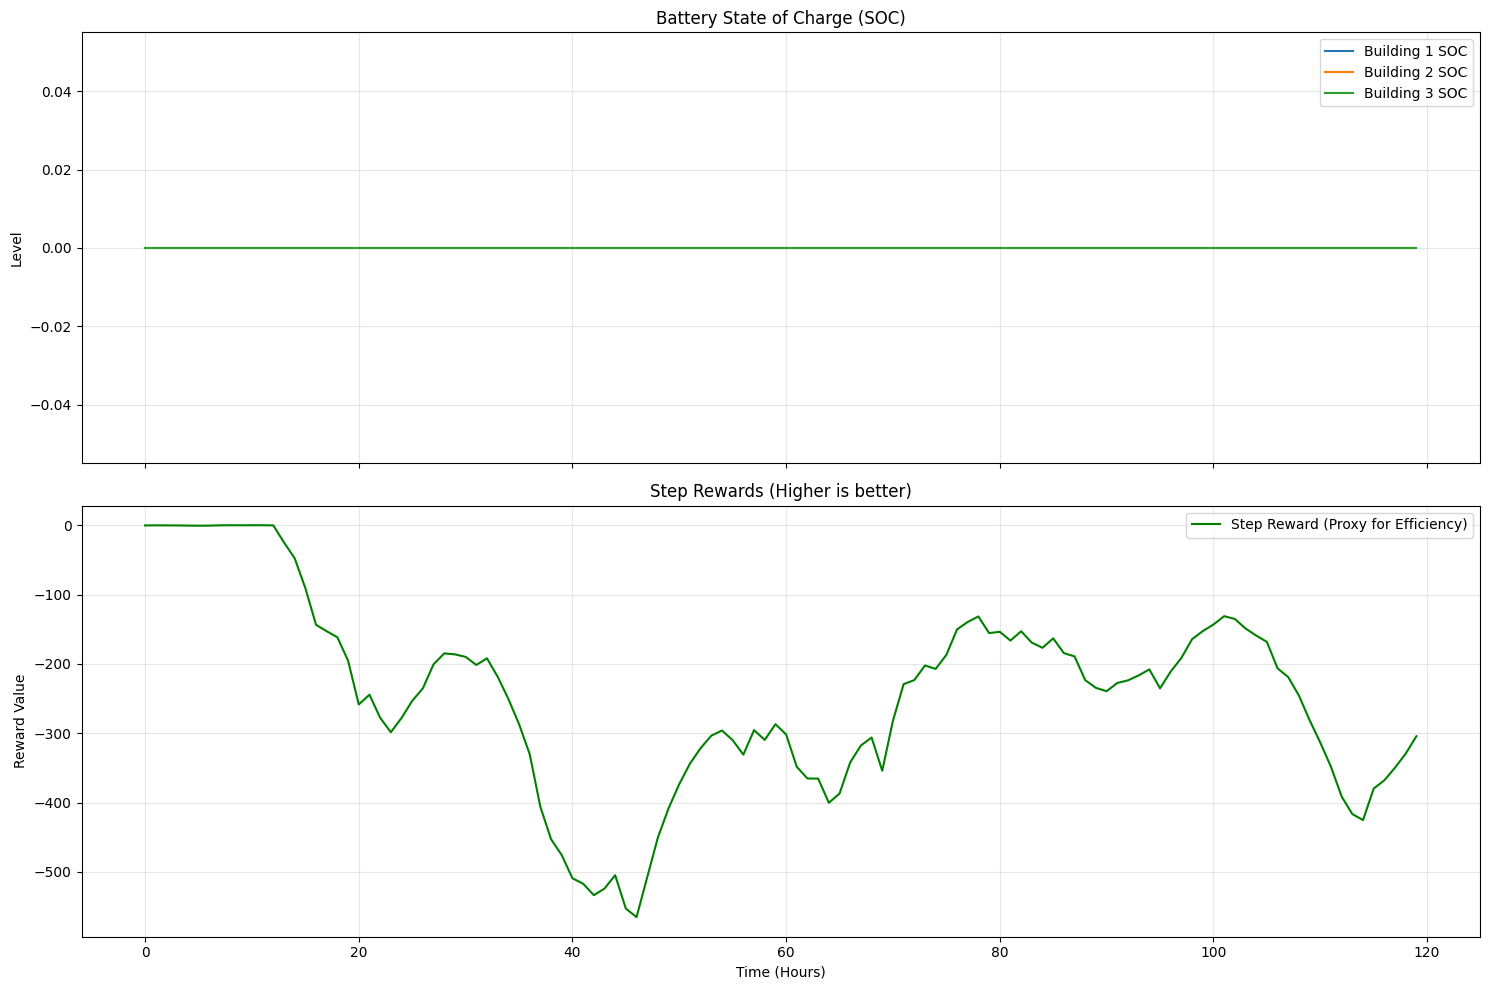

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Сброс среды
obs, _ = env.reset()
soc_data = [[] for _ in range(len(env.buildings))]
net_consumption = []

steps = 120 

for _ in range(steps):
    # Используем "ручные" нулевые действия
    manual_actions = [[0.0] * 9] 

    # Делаем шаг. Нам нужны reward и info
    obs, reward, info, terminated, truncated = env.step(manual_actions)
    
    # 1. Достаем SOC. Если атрибут напрямую недоступен, 
    # он всегда есть в векторе obs (нужно только знать индекс).
    # Но попробуем сначала через электрическое хранилище:
    for i, building in enumerate(env.buildings):
        # В некоторых версиях доступ идет через .electrical_storage.soc_history
        try:
            val = building.electrical_storage.soc[-1]
        except:
            # Если не вышло, берем из вектора obs (обычно SOC в конце списка признаков здания)
            val = obs[0][-(len(env.buildings)-i)] # Грубая прикидка индекса
        soc_data[i].append(val)
    
    # 2. Достаем потребление. В CityLearn награда часто 
    # коррелирует с net_consumption. Или берем сумму из reward.
    # Суммарная награда за шаг для всех зданий:
    net_consumption.append(np.sum(reward))

# 2. Отрисовка
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for i in range(len(soc_data)):
    ax1.plot(soc_data[i], label=f'Building {i+1} SOC')
ax1.set_title('Battery State of Charge (SOC)')
ax1.set_ylabel('Level')
ax1.legend()
ax1.grid(True, alpha=0.3)

# На графике будет "Reward", который в CityLearn по сути отражает Net Consumption (со знаком минус)
ax2.plot(net_consumption, color='green', label='Step Reward (Proxy for Efficiency)')
ax2.set_title('Step Rewards (Higher is better)')
ax2.set_ylabel('Reward Value')
ax2.set_xlabel('Time (Hours)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Посмотрим имена всех признаков в состоянии
for i, name in enumerate(env.observation_names[0]):
    if 'soc' in name or 'hour' in name:
        print(f"Индекс {i}: {name}")
    

Индекс 1: hour
Индекс 18: dhw_storage_soc
Индекс 19: electrical_storage_soc
Индекс 33: dhw_storage_soc
Индекс 34: electrical_storage_soc
Индекс 44: dhw_storage_soc
Индекс 45: electrical_storage_soc


## Пробуем подключится к llm 

In [11]:
import openai
import re

client = openai.OpenAI(base_url="http://localhost:8000/v1", api_key="no-key")

def get_llm_action(soc, reward_proxy):
    # Упрощаем промпт до предела, чтобы CPU не кипел
    # Объясняем модели, что отрицательное значение - разрядка, положительное - зарядка
    prompt = f"Context: SoC={soc:.2f}, LastReward={reward_proxy:.2f}. Task: Output only a single float number between -1.0 and 1.0 for battery control."
    
    try:
        response = client.chat.completions.create(
            model="qwen",
            messages=[{"role": "system", "content": "You are a battery controller. Output ONLY a number."},
                      {"role": "user", "content": prompt}],
            max_tokens=10,
            temperature=0
        )
        res_text = response.choices[0].message.content.strip()
        # Извлекаем число из строки (на случай если модель допишет что-то лишнее)
        action = float(re.findall(r"[-+]?\d*\.\d+|\d+", res_text)[0])
        return max(min(action, 1.0), -1.0) # Ограничиваем диапазон
    except Exception as e:
        print(f"Error: {e}")
        return 0.0 # В случае ошибки — ничего не делаем

In [12]:
for step_idx in range(steps):
    # Берем текущий SOC первого здания для примера
    current_soc = soc_data[0][-1] if step_idx > 0 else 0.5
    last_reward = net_consumption[-1] if step_idx > 0 else 0.0
    
    # Спрашиваем LLM
    llm_decision = get_llm_action(current_soc, last_reward)
    
    # Формируем действия. В CityLearn обычно действия передаются как список списков.
    # Для примера даем всем зданиям одну и ту же команду от LLM
    actions = [[llm_decision] * 9 for _ in range(len(env.buildings))] 

    # Шаг в среде
    obs, reward, info, terminated, truncated = env.step(actions)
    
    # Сбор данных для графиков
    for i, building in enumerate(env.buildings):
        try:
            val = building.electrical_storage.soc[-1]
        except:
            val = obs[0][-(len(env.buildings)-i)]
        soc_data[i].append(val)
    
    net_consumption.append(np.sum(reward))
    
    if step_idx % 10 == 0:
        print(f"Step {step_idx}: LLM Action = {llm_decision:.2f}, SoC = {current_soc:.2f}")

INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


Step 0: LLM Action = 0.50, SoC = 0.50


INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


Step 10: LLM Action = 0.00, SoC = 0.00


INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


...

INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


Step 100: LLM Action = 0.00, SoC = 0.00


INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


Step 110: LLM Action = 0.00, SoC = 0.00


INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


## Допиливание

Starting simulation with LLM Agent...


INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


LLM Reasoning: Price is low and battery SoC is 0.0 (empty). I will charge to fill the battery up.


Day 0: Processing...


INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


LLM Reasoning: Price is low at 0.1, and the battery SoC is critical (0.0). I will charge to maximize energy efficiency.




...

LLM Reasoning: Price is low at 0.1, which is ideal for charging the battery to avoid it becoming empty. 


INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


LLM Reasoning: Price is low at 0.1, which is ideal for charging the battery to avoid critical SoC levels. 


INFO:httpx:HTTP Request: POST http://localhost:8000/v1/chat/completions "HTTP/1.1 200 OK"


LLM Reasoning: Price is low at 0.1, and the battery SoC is critical (0.0). I will charge to improve the battery's health.


Simulation finished!


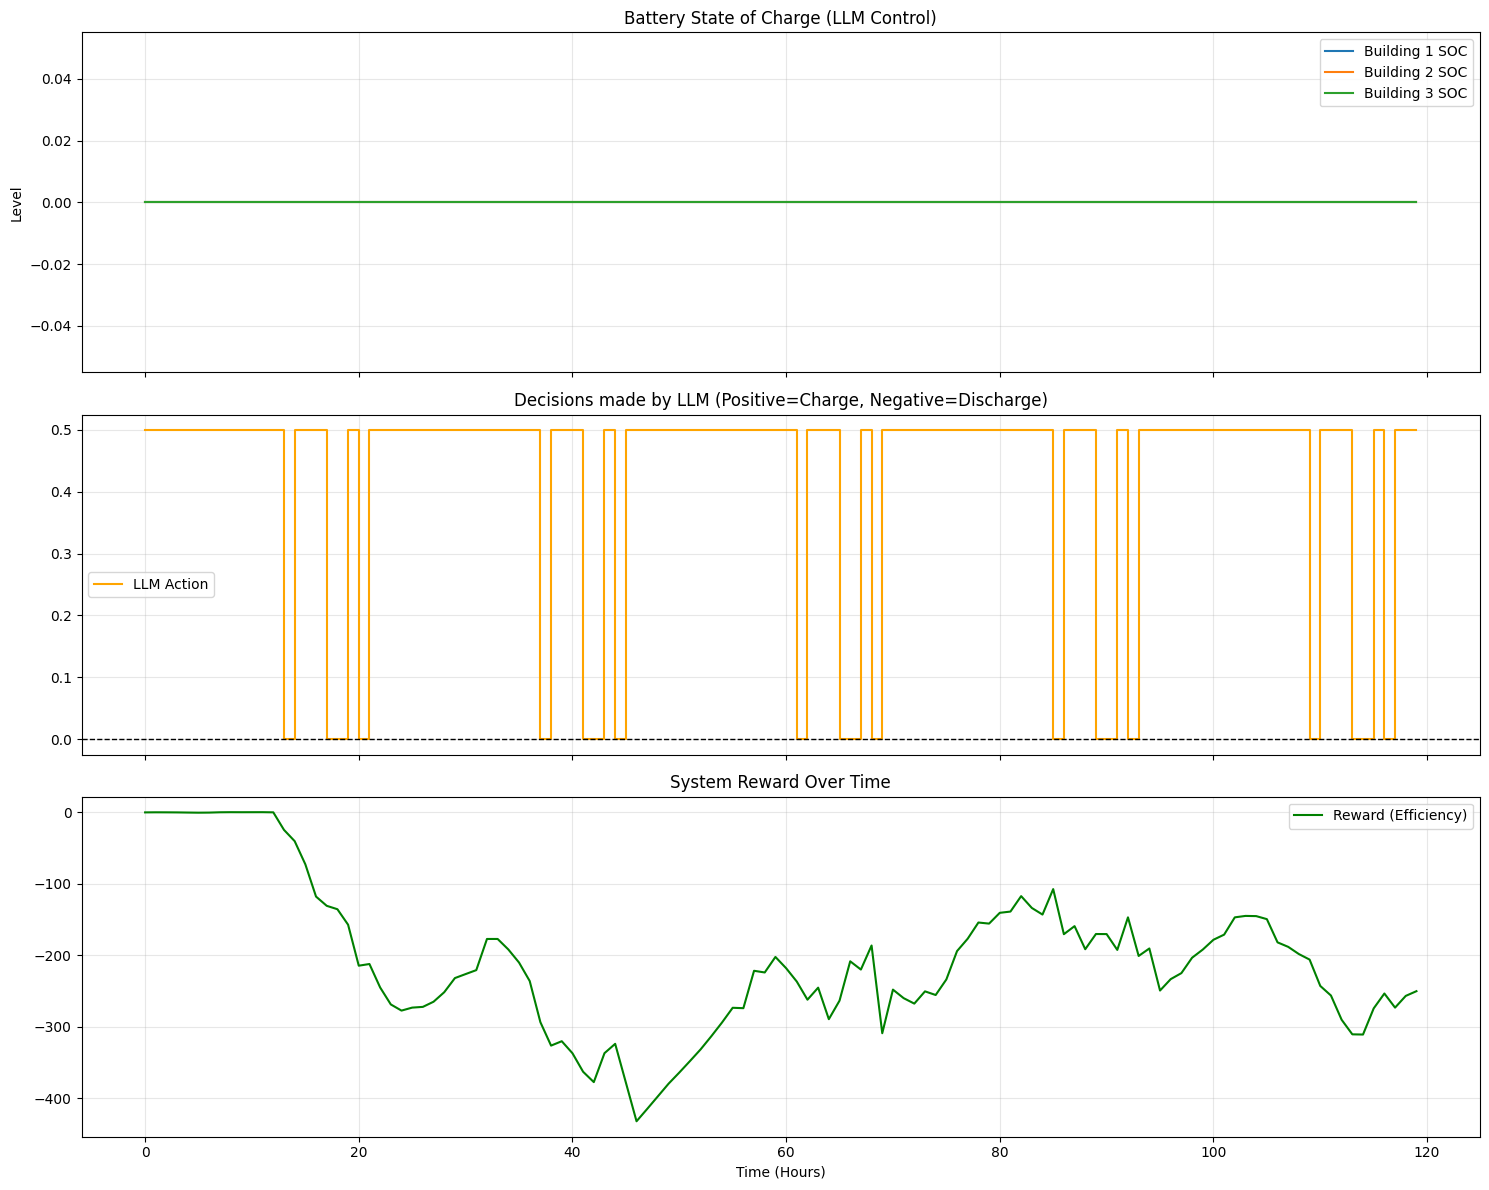

In [20]:
import openai
import re
import numpy as np
import matplotlib.pyplot as plt

# 1. Настройка клиента
client = openai.OpenAI(base_url="http://localhost:8000/v1", api_key="no-key")

# def get_llm_action(soc, hour, price):
#     """Функция запроса к локальной Qwen"""
#     prompt = f"Hour:{hour}, SoC:{soc:.2f}, Price:{price:.2f}. Task: Battery action (-1 to 1). Result:"
#     try:
#         response = client.chat.completions.create(
#             model="qwen",
#             messages=[
#                 {"role": "system", "content": "You are an energy optimizer. Output only a float number between -1.0 and 1.0."},
#                 {"role": "user", "content": prompt}
#             ],
#             max_tokens=10,
#             temperature=0
#         )
#         res_text = response.choices[0].message.content.strip()
#         # Ищем число в ответе через регулярку
#         match = re.search(r"[-+]?\d*\.\d+|\d+", res_text)
#         action = float(match.group()) if match else 0.0
#         return max(min(action, 1.0), -1.0)
#     except:
#         return 0.0

def get_llm_action(soc, hour, price):
    # Добавляем в промпт стратегию (хинт для модели)
    prompt = f"""[System: Energy Optimizer]
Context:
- Hour: {hour}:00
- Battery SoC: {soc:.2f} (0.0=empty, 1.0=full)
- Electricity Price: {price:.2f}

Strategy: 
1. Charge (positive action) when price is low (0.1) or SoC is critical.
2. Discharge (negative action) when price is high (0.5) to save money.

Task: Briefly explain your reasoning and end with 'Action: [number]'.
Example: Price is low and battery is empty. I will charge. Action: 0.5"""

    try:
        response = client.chat.completions.create(
            model="qwen",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=60, # Увеличили, чтобы влезло объяснение
            temperature=0
        )
        res_text = response.choices[0].message.content.strip()
        
        # Логируем объяснение в консоль, чтобы видеть "мозги" модели
        print(f"LLM Reasoning: {res_text.split('Action:')[0]}")
        
        # Вытаскиваем только число после слова Action:
        match = re.search(r"Action:\s*([-+]?\d*\.\d+|\d+)", res_text)
        action = float(match.group(1)) if match else 0.0
        return max(min(action, 0.5), -0.5) # Ограничим силу действия для стабильности
    except Exception as e:
        print(f"Parse Error: {e}")
        return 0.0

# 2. Инициализация логов
obs, _ = env.reset()
soc_data = [[] for _ in range(len(env.buildings))]
net_consumption = []
actions_history = []

steps = 120 # 5 суток симуляции

print("Starting simulation with LLM Agent...")

for step_idx in range(steps):
    # Извлекаем данные из obs (индексы стандартные для CityLearn)
    # Обычно: hour (индекс 2), price (индекс 23-25 в зависимости от схемы)
    # Для простоты возьмем час из внутреннего счетчика среды
    hour = (step_idx) % 24 
    
    # Берем SoC первого здания
    try:
        current_soc = env.buildings[0].electrical_storage.soc[-1]
    except:
        current_soc = obs[0][-1] # берем из последнего элемента вектора

    # Запрашиваем действие у LLM
    # Для теста передадим фиксированную "высокую" цену, если час пик (18-22)
    current_price = 0.5 if 18 <= hour <= 22 else 0.1
    
    llm_decision = get_llm_action(current_soc, hour, current_price)
    actions_history.append(llm_decision)

    # Формируем вектор действий для всех зданий и всех подсистем (их 9)
    # actions = [[llm_decision] * 9 for _ in range(len(env.buildings))]
    actions = [[0.0]*8 + [llm_decision] for _ in range(len(env.buildings))]

    # Шаг в среде
    obs, reward, info, terminated, truncated = env.step(actions)
    
    # Сбор данных
    for i, building in enumerate(env.buildings):
        soc_data[i].append(building.electrical_storage.soc[-1])
    net_consumption.append(np.sum(reward))

    if step_idx % 24 == 0:
        print(f"Day {step_idx//24}: Processing...")

print("Simulation finished!")

# 3. Визуализация
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for i in range(len(soc_data)):
    ax1.plot(soc_data[i], label=f'Building {i+1} SOC')
ax1.set_title('Battery State of Charge (LLM Control)')
ax1.set_ylabel('Level')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(actions_history, color='orange', drawstyle='steps-post', label='LLM Action')
ax2.axhline(0, color='black', lw=1, ls='--')
ax2.set_title('Decisions made by LLM (Positive=Charge, Negative=Discharge)')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(net_consumption, color='green', label='Reward (Efficiency)')
ax3.set_title('System Reward Over Time')
ax3.set_xlabel('Time (Hours)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Посчитаем суммарный штраф (чем ближе к 0, тем лучше)
llm_score = np.sum(net_consumption)
print(f"Итоговый скор LLM: {llm_score:.2f}")

Итоговый скор LLM: -24724.44


## Сравнение

In [22]:
# 1. Сброс для чистого теста
obs, _ = env.reset()
net_consumption_baseline = []

for step_idx in range(steps):
    # Просто ничего не делаем (пассивная стратегия)
    actions = [[0.0] * 9 for _ in range(len(env.buildings))]
    obs, reward, info, terminated, truncated = env.step(actions)
    net_consumption_baseline.append(np.sum(reward))

baseline_score = np.sum(net_consumption_baseline)
print(f"Итоговый скор Baseline (без LLM): {baseline_score:.2f}")
print(f"Разница: {llm_score - baseline_score:.2f}")

Итоговый скор Baseline (без LLM): -29226.58
Разница: 4502.14
